# Simulating Randomness and Random Numbers
     Instructor: Jarrian Vince G. Gojar

## Introduction

This notebook covers the fundamentals of computer simulation, focusing on the essential role of **random number generation**. We'll explore why and how simulations are used, the concept of pseudorandomness, and methods for generating random numbers following various distributions.

A simulation is a computer program that **imitates reality** to study situations and make decisions. We use them when:
* Actual experiments are **not feasible** or the system **doesn't exist**.
* The **cost** (money, time, danger) of real experiments is **prohibitive**.
* We need to **test alternatives** efficiently.

***
## Element of Chance: Pseudorandom Numbers

At the core of most simulations is **random number generation**. Since a computer follows deterministic instructions, the numbers generated are called **pseudorandom numbers**.

* **Pseudorandom:** Generated by an algorithm (an equation or set of rules), meaning the sequence is entirely predictable if the starting point (the **seed**) is known. They only *appear* to be random.
* **Monte Carlo Simulation:** Any simulation involving a probabilistic model and an element of chance is often referred to as a Monte Carlo simulation. 

### Multiplicative Linear Congruential Method (MLCM)

The MLCM is a common algorithm for generating a sequence of pseudorandom integers: 

$$\text{random}_n = (\text{multiplier} \times \text{random}_{n-1}) \bmod \text{modulus}, \text{ for } n > 0$$

A floating-point number $\text{rand}$ in $[0.0, 1.0)$ is then derived by dividing the integer by the modulus:

$$\text{rand} = \frac{\text{random}_n}{\text{modulus}}$$

Let's implement the example from the slides.

In [88]:
def mlcm_generator(seed, multiplier, modulus, count):
    """Generates a sequence of pseudorandom integers and floating-point numbers."""
    random_n = seed
    integers = [random_n]
    
    for _ in range(count - 1):
        random_n = (multiplier * random_n) % modulus
        integers.append(random_n)
        
    # Convert to floating point numbers in [0.0, 1.0)
    floats = [i / modulus for i in integers]
    
    return integers, floats

seed = 10
multiplier = 7
modulus = 11
count = 10

integers, floats = mlcm_generator(seed, multiplier, modulus, count)

print(f"Seed: {seed}, Multiplier: {multiplier}, Modulus: {modulus}")
print(f"\nGenerated Integers: {integers}")
print(f"Generated Floats (First 5): {[round(f, 4) for f in floats[:5]]}")

Seed: 10, Multiplier: 7, Modulus: 11

Generated Integers: [10, 4, 6, 9, 8, 1, 7, 5, 2, 3]
Generated Floats (First 5): [0.9091, 0.3636, 0.5455, 0.8182, 0.7273]


***
## Transforming Uniform Random Numbers

The fundamental random number $\text{rand} \in [0.0, 1.0)$ needs to be scaled and shifted to fit the simulation's required range.

### 1. Random Floating Point Number $\text{min} \le r < \text{max}$

$$r = (\text{max} - \text{min}) \times \text{rand} + \text{min}$$

### 2. Random Integer $\text{min} \le n \le \text{max}$ (Inclusive)

$$n = \text{int}((\text{max} - \text{min} + 1) \times \text{rand} + \text{min})$$

In [89]:
import random

# Example 1: Floating Point between 20.0 and 26.3
min_f = 20.0
max_f = 26.3
rand_f = random.random() # Assumes a new rand in [0.0, 1.0)
r = (max_f - min_f) * rand_f + min_f
print(f"Floating Point ({min_f} to {max_f}): {r:.4f}")

# Example 2: Integer between 20 and 26 (inclusive)
min_i = 20
max_i = 26
rand_i = random.random() # Assumes a new rand in [0.0, 1.0)
n = int((max_i - min_i + 1) * rand_i + min_i)
print(f"Integer ({min_i} to {max_i} inclusive): {n}")

# Python's built-in equivalent
print(f"\nPython's built-in integer method: {random.randint(min_i, max_i)}")

Floating Point (20.0 to 26.3): 25.6574
Integer (20 to 26 inclusive): 20

Python's built-in integer method: 20


***
## Distributions: Discrete vs. Continuous

The **distribution** describes the portion of times each possible outcome occurs. 

### 1. Discrete Distribution (Unequal Probabilities)

To generate random events $e_1, e_2, \dots, e_n$ with specific probabilities $p_1, p_2, \dots, p_n$ (where $\sum p_i = 1$), we use the **cumulative probability** method. We map the uniform $\text{rand} \in [0, 1)$ to a specific event by checking which cumulative range it falls into.

**Example:** Simulating a coin toss where heads has a 70% chance ($p_H=0.7$) and tails has a 30% chance ($p_T=0.3$).
* If $\text{rand} < 0.7$ (i.e., $p_H$), return **Heads**.
* Else ($\text{rand} \ge 0.7$), return **Tails**.

In [90]:
def discrete_simulator(events_probs):
    """Generates a random event based on a dictionary of {event: probability}."""
    rand = random.random() # Uniform random number in [0.0, 1.0)
    cumulative_prob = 0.0
    
    for event, prob in events_probs.items():
        cumulative_prob += prob
        if rand < cumulative_prob:
            return event
            
    # Fallback (shouldn't happen if probabilities sum to 1)
    return list(events_probs.keys())[-1]
    
biased_coin = {"Heads": 0.7, "Tails": 0.3}
results = [discrete_simulator(biased_coin) for _ in range(10000)]

head_count = results.count("Heads")
tail_count = results.count("Tails")

print(f"Simulation of 10,000 biased tosses:")
print(f"Heads Count: {head_count} ({head_count/10000:.2f})")
print(f"Tails Count: {tail_count} ({tail_count/10000:.2f})")

Simulation of 10,000 biased tosses:
Heads Count: 6952 (0.70)
Tails Count: 3048 (0.30)


***
## Continuous Distributions: Advanced Methods

### 2. Normal (Gaussian) Distribution

This is the famous **Bell Curve**, defined by the mean ($\mu$) and standard deviation ($\sigma$). Generating numbers from this distribution often uses the **Box-Muller-Gauss Method**, which converts two uniform random numbers into two independent normally distributed numbers.

We use the `numpy` library in Python for efficiency, which internally uses algorithms like Box-Muller.

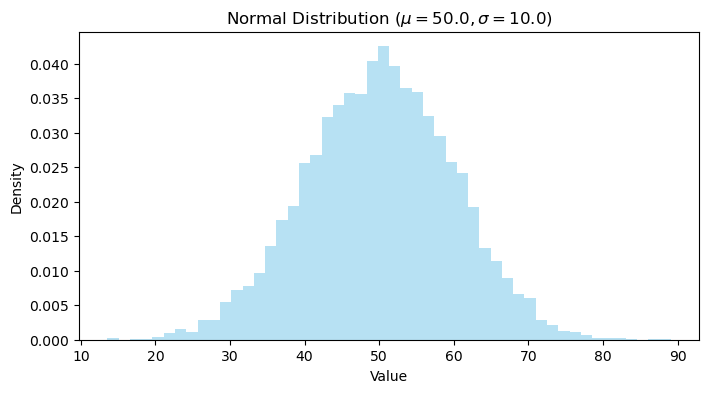

In [86]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters for the Normal Distribution
mu = 50.0   # Mean (e.g., average test score)
sigma = 10.0 # Standard Deviation (e.g., variability of scores)
num_samples = 10000

# Generate random numbers using a built-in method (based on Box-Muller)
normal_samples = np.random.normal(loc=mu, scale=sigma, size=num_samples)

# Plot the results to visualize the Bell Curve
plt.figure(figsize=(8, 4))
plt.hist(normal_samples, bins=50, density=True, alpha=0.6, color='skyblue')
plt.title(f'Normal Distribution ($\mu={mu}, \sigma={sigma}$)')
plt.xlabel('Value')
plt.ylabel('Density')
plt.show()

### 3. Exponential Distribution

Used to model the time between events. It is often generated using the **Inverse Transform Sampling** method, where you solve the inverse of the Cumulative Distribution Function (CDF). 

For the Exponential distribution, this results in the formula:

$$t = -\frac{1}{r} \ln(\text{rand})$$

where $r$ is the **rate** parameter (or $1/\lambda$, the mean time between events).

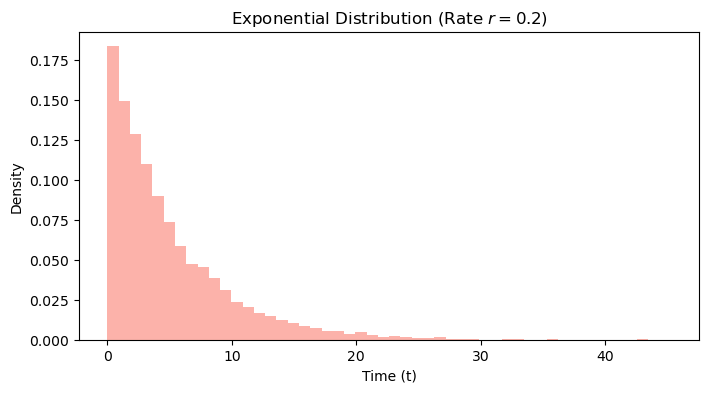

In [87]:
# Example: Simulating the time (t) between calls, where the average time is 5 minutes (Rate r = 1/5 = 0.2)
rate_r = 0.2  # The rate parameter
num_samples = 10000

# Implementation of the Inverse Transform Method
rand_samples = np.random.rand(num_samples)
t_samples = -np.log(rand_samples) / rate_r

plt.figure(figsize=(8, 4))
plt.hist(t_samples, bins=50, density=True, alpha=0.6, color='salmon')
plt.title(f'Exponential Distribution (Rate $r={rate_r}$)')
plt.xlabel('Time (t)')
plt.ylabel('Density')
plt.show()

***
## The Rejection Method

The **Rejection Method** is a general-purpose approach used when direct transformation methods (like the ones above) are not feasible for a complex distribution $f(x)$.

**Core Idea:**
1.  **Select a point** $x$ (from a uniform range $[a, b]$) and a random height $y$ (from $[0, \text{max}(f(x))])$.
2.  **Check:** If the height $y$ is below the curve, $y < f(x)$, **accept** $x$.
3.  **Reject:** If $y \ge f(x)$, **reject** $x$ and try again.

This simulates 'throwing darts' at the area under the curve and only keeping the darts that hit the target region, thus sampling the desired distribution.